# Notebook 01 — Packet-Counter Reconstruction
**Thesis §4.2 | Input:** `data/0_cleaned_dataset_Obiri_2025_v2.csv` | **Output:** `data/1_reconstructed.csv`

---

## What this notebook does

Implements the packet-counter reconstruction pipeline described in §4.2 of the thesis.

| Step | Thesis section | Description |
|------|---------------|-------------|
| 0 | — | Imports, paths, plot style |
| 1 | §4.1 | Load and sort raw dataset |
| 2 | §4.2.1 | Reconstruction — derive $N_{\text{tx-loss}}$ and $N_{\text{fw-drop}}$ |
| 3 | §4.2.2 | Counter reset detection and removal |
| 4 | §4.2.1 | Counter divergence figure (Fig 01_a) — computed on clean data |
| 5 | §4.2.3 | Infrastructure outage detection |
| 6 | §4.2.4 | Loss classification and packet decomposition (Fig 01_c) |
| 7 | §4.2.5 | PDR decomposition (Fig 01_d) |
| 8 | §4.2.5 | Per-device loss breakdown |
| 9 | — | Save reconstructed dataset |

**Variable naming convention:**

| Variable | Symbol | Meaning |
|----------|--------|---------|
| `tx_loss` | $N_{\text{tx-loss}}^{(i)}$ | Transmitted but lost — primary radio-layer loss metric |
| `fw_drop` | $N_{\text{fw-drop}}^{(i)}$ | Firmware drop before radio transmission |
| `t_radio` | $T_{\text{radio}}^{(i)}$ | Total radio transmission attempts |
| `t_sched` | $T_{\text{sched}}^{(i)}$ | Total scheduled transmissions |


## 0 · Imports & Paths

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path('../data')
FIG_DIR = Path('../figures')
FIG_DIR.mkdir(exist_ok=True)

RAW_CSV = DATA_DIR / '0_cleaned_dataset_Obiri_2025_v2.csv'
OUT_CSV = DATA_DIR / '1_reconstructed.csv'

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 12, 'axes.titlesize': 13,
    'axes.labelsize': 13, 'xtick.labelsize': 12, 'ytick.labelsize': 12,
    'legend.fontsize': 11, 'figure.dpi': 150, 'savefig.dpi': 300,
    'savefig.bbox': 'tight', 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
})

C = {
    'blue': '#0077BB', 'orange': '#EE7733', 'green': '#009988',
    'red': '#CC3311', 'purple': '#AA3377', 'navy': '#004488',
    'grey': '#BBBBBB', 'brown': '#882255',
}
DEVICE_COLORS = [C['blue'], C['orange'], C['green'], C['red'], C['purple'], C['navy']]


def save_fig(fig, name):
    fig.savefig(FIG_DIR / f'{name}.pdf')
    fig.savefig(FIG_DIR / f'{name}.png')
    print(f'  Saved: figures/{name}')
    plt.show()


print(f'Ready. Data    → {DATA_DIR.resolve()}')
print(f'       Figures → {FIG_DIR.resolve()}')

Ready. Data    → D:\Thesis\lorawan_master_thesis\data
       Figures → D:\Thesis\lorawan_master_thesis\figures


## 1 · Load & Sort  *(§4.1)*

Timestamps parsed as UTC. Rows sorted per device by time before any processing.


In [20]:
df = pd.read_csv(RAW_CSV)
df['time'] = pd.to_datetime(df['time'], utc=True)
df = df.sort_values(['device_id', 'time']).reset_index(drop=True)

print(f'Rows    : {len(df):,}')
print(f'Devices : {sorted(df["device_id"].unique())}')
print(f'Period  : {df["time"].min().date()} → {df["time"].max().date()}')
print(f'SF range: SF{int(df["SF"].min())}–SF{int(df["SF"].max())}')
print()
print(f'{"Device":<10} {"Rows":>12} {"% of total":>12}')
print('-' * 36)
for dev, g in df.groupby('device_id'):
    n = len(g)
    print(f'{dev:<10} {n:>12,} {n / len(df) * 100:>11.2f}%')
print('-' * 36)
print(f'{"Total":<10} {len(df):>12,} {"100.00%":>12}')

Rows    : 2,634,930
Devices : ['ED0', 'ED1', 'ED2', 'ED3', 'ED4', 'ED5']
Period  : 2024-10-01 → 2025-09-30
SF range: SF7–SF12

Device             Rows   % of total
------------------------------------
ED0             440,166       16.71%
ED1             434,548       16.49%
ED2             440,920       16.73%
ED3             433,579       16.46%
ED4             435,416       16.52%
ED5             450,301       17.09%
------------------------------------
Total         2,634,930      100.00%


## 2 · Reconstruction Algorithm  *(§4.2.1)*

**Counter definitions:**
- `f_count` = FCntUp — incremented by the end-device with each uplink transmission
- `p_count` = application counter — incremented by firmware for every scheduled packet

**Derived variables (thesis naming convention):**

| Column | Symbol | Meaning |
|--------|--------|---------|
| `tx_loss` | $N_{\text{tx-loss}}^{(i)}$ | $\max(0, \Delta f_i - 1)$ — transmitted but lost |
| `fw_drop` | $N_{\text{fw-drop}}^{(i)}$ | $\max(0, \Delta p_i - \Delta f_i)$ — firmware drop before radio |
| `t_radio` | $T_{\text{radio}}^{(i)}$ | $1 + N_{\text{tx-loss}}^{(i)}$ — total radio attempts |
| `t_sched` | $T_{\text{sched}}^{(i)}$ | $1 + N_{\text{tx-loss}}^{(i)} + N_{\text{fw-drop}}^{(i)}$ — total scheduled |


In [21]:
def reconstruct(grp):
    """
    Reconstruct tx_loss and fw_drop for one device.
    Rows must be sorted by time (guaranteed by Cell 1).
    Reset intervals (delta_f < 0) are flagged and zeroed — the true
    loss count during a device reboot is unrecoverable from the counter alone.
    """
    grp = grp.copy().reset_index(drop=True)
    delta_f = grp['f_count'].diff()
    delta_p = grp['p_count'].diff()

    is_reset = delta_f < 0  # device rebooted

    # N_tx-loss: transmitted but never arrived at network server
    tx_loss = (delta_f - 1).clip(lower=0)
    tx_loss[is_reset] = 0  # reset intervals uninformative
    tx_loss.iloc[0] = 0  # first row has no predecessor

    # N_fw-drop: scheduled by firmware but dropped before radio
    fw_drop = (delta_p - delta_f).clip(lower=0)
    fw_drop[is_reset] = 0
    fw_drop.iloc[0] = 0

    grp['tx_loss'] = tx_loss.astype(int)
    grp['fw_drop'] = fw_drop.astype(int)
    grp['t_radio'] = 1 + grp['tx_loss']  # T_radio: radio transmission attempts
    grp['t_sched'] = 1 + grp['tx_loss'] + grp['fw_drop']  # T_sched: all scheduled
    grp['is_reset'] = is_reset.fillna(False)
    return grp


device_ids = df['device_id'].copy()
df = df.groupby('device_id', group_keys=False).apply(reconstruct)
df['device_id'] = device_ids.values
df = df.reset_index(drop=True)

print('Reconstruction complete.')
print(f'  tx_loss total  (N_tx-loss) : {df["tx_loss"].sum():,}')
print(f'  fw_drop total  (N_fw-drop) : {df["fw_drop"].sum():,}')
print(f'  is_reset total             : {df["is_reset"].sum():,}')

Reconstruction complete.
  tx_loss total  (N_tx-loss) : 259,244
  fw_drop total  (N_fw-drop) : 251,370
  is_reset total             : 27


In [22]:
# Where do losses concentrate by SF?
loss_by_sf = df.groupby('SF')[['fw_drop', 'tx_loss']].sum()
loss_by_sf['fw_drop_pct'] = loss_by_sf['fw_drop'] / loss_by_sf['fw_drop'].sum() * 100
loss_by_sf['tx_loss_pct'] = loss_by_sf['tx_loss'] / loss_by_sf['tx_loss'].sum() * 100
print(loss_by_sf)

# Sanity-check ToA per SF (should be constant)
print(df.groupby('SF')['toa'].agg(['mean', 'nunique']))

# Confirm the 5-per-SF rotation pattern
print(df.groupby('SF').size())

    fw_drop  tx_loss  fw_drop_pct  tx_loss_pct
SF                                            
7      3859    41906     1.535187    16.164694
8     14590    54231     5.804193    20.918903
9     50686    47166    20.163902    18.193671
10    28129    46072    11.190277    17.771675
11    79413    29604    31.592075    11.419358
12    74693    40265    29.714365    15.531700
        mean  nunique
SF                   
7   0.071962        2
8   0.133667        2
9   0.246882        2
10  0.452805        2
11  0.986759        2
12  1.811038        2
SF
7     537023
8     534546
9     518734
10    500838
11    269220
12    274569
dtype: int64


## 3 · Counter Reset Detection  *(§4.2.2)*

A device reboot resets `f_count` to zero, producing a large negative $\Delta f_i$.
Without handling, such intervals inflate `tx_loss` by thousands.
Every interval where $\Delta f_i < 0$ is flagged as a reset, its `tx_loss` forced
to zero, and excluded from all loss computations.


In [23]:
print(f'{"Device":<10} {"Resets":>8}')
print('-' * 20)
for dev, g in df.groupby('device_id'):
    print(f'{dev:<10} {int(g["is_reset"].sum()):>8}')
print('-' * 20)
print(f'{"Total":<10} {int(df["is_reset"].sum()):>8}')
print()
print('Reset intervals: tx_loss set to 0, excluded from all loss computations.')

Device       Resets
--------------------
ED0               8
ED1               3
ED2               3
ED3               6
ED4               2
ED5               5
--------------------
Total            27

Reset intervals: tx_loss set to 0, excluded from all loss computations.


## 4 · Infrastructure Outage Detection  *(§4.2.3)*

**Definition:** a period during which all six end devices simultaneously failed
to deliver data for longer than 6 minutes. Six minutes is the worst-case
transmission interval — with one packet per device per 60 seconds, any 6-minute
window is guaranteed to contain at least one packet from every device under
normal operating conditions.

**Algorithm:** for each device, find all silence gaps exceeding 6 minutes.
A confirmed outage is the intersection of overlapping silence intervals across
all six devices, subject to a minimum duration of 6 minutes.


In [24]:
import pandas as pd

# ──────────────────────────────────────────────────────────────────────────
# Gap distribution check (per device, per SF)
# ──────────────────────────────────────────────────────────────────────────
gaps_by_sf = []
for dev in sorted(df['device_id'].unique()):
    d = df[df['device_id'] == dev].sort_values('time')
    d = d.assign(gap_min=(d['time'].diff().dt.total_seconds() / 60))
    d = d.dropna(subset=['gap_min'])
    gaps_by_sf.append(d[['SF', 'gap_min']])

all_gaps = pd.concat(gaps_by_sf)

print("Gap distribution by SF (minutes):")
print(all_gaps.groupby('SF')['gap_min'].describe(
    percentiles=[.5, .75, .90, .95, .99]).round(2).to_string())

print(f"\nGaps > 10 min : {(all_gaps['gap_min'] > 10).sum():,}")
print(f"Gaps > 20 min : {(all_gaps['gap_min'] > 20).sum():,}")
print(f"Gaps > 30 min : {(all_gaps['gap_min'] > 30).sum():,}")
print(f"Gaps > 60 min : {(all_gaps['gap_min'] > 60).sum():,}")

# ──────────────────────────────────────────────────────────────────────────
# Infrastructure outage detection
#
# Threshold: 4 minutes. The 99th-percentile single-device inter-packet
# gap is 3.03 min (observed at SF12, under EU868 1% duty-cycle
# enforcement). Each device is scheduled to transmit once per minute,
# so a 4-minute silence leaves every device at least one further
# scheduling opportunity beyond this worst-case gap. A confirmed
# outage requires this silence to hold simultaneously across all six
# devices, which is the common-mode signature of a shared
# infrastructure failure (gateway, network server, or backend) rather
# than independent per-device behaviour.
# ──────────────────────────────────────────────────────────────────────────
DEVICES = sorted(df['device_id'].unique().tolist())
MIN_DURATION = 4  # minutes

# Step 1: silence gaps per device
device_gaps = {}
for dev in DEVICES:
    times = (
        df[df['device_id'] == dev]
        .sort_values('time')['time']
        .reset_index(drop=True)
    )
    gaps = []
    for i in range(1, len(times)):
        gap_min = (times[i] - times[i - 1]).total_seconds() / 60
        if gap_min > MIN_DURATION:
            gaps.append({'start': times[i - 1], 'end': times[i]})
    device_gaps[dev] = gaps

# Step 2: find overlapping silences across ALL 6 devices
raw_outages = []

for base_dev in DEVICES:
    for base_gap in device_gaps[base_dev]:
        overlap_start = base_gap['start']
        overlap_end = base_gap['end']
        valid = True

        for dev in DEVICES:
            if dev == base_dev:
                continue
            found = False
            for gap in device_gaps[dev]:
                latest_start = max(overlap_start, gap['start'])
                earliest_end = min(overlap_end, gap['end'])
                if latest_start < earliest_end:
                    overlap_start = latest_start
                    overlap_end = earliest_end
                    found = True
                    break
            if not found:
                valid = False
                break

        if valid:
            duration_min = (overlap_end - overlap_start).total_seconds() / 60
            if duration_min >= MIN_DURATION:
                raw_outages.append({
                    'start_time': overlap_start,
                    'end_time': overlap_end,
                    'duration_minutes': duration_min,
                    'duration_hours': duration_min / 60,
                    'duration_days': duration_min / 1440,
                })

# Step 3: deduplicate and sort
outages_df = (
    pd.DataFrame(raw_outages)
    .drop_duplicates(subset=['start_time', 'end_time'])
    .sort_values('start_time')
    .reset_index(drop=True)
)

# Step 4: flag outage intervals in df
df['is_outage'] = False
for _, outage in outages_df.iterrows():
    mask = (
            (df['time'] >= outage['start_time']) &
            (df['time'] <= outage['end_time'])
    )
    df.loc[mask, 'is_outage'] = True

# Summary
total_min = outages_df['duration_minutes'].sum()
print(f'Confirmed outage events  : {len(outages_df)}')
print(f'Total downtime           : {total_min:.0f} min'
      f' / {total_min / 60:.1f} hrs'
      f' / {total_min / 1440:.1f} days')
print(f'Outage intervals in df   : {df["is_outage"].sum():,}')
print()
print(f'{"Ev":^4} {"Date":^12} {"Start":^8} {"End":^8} {"Dur(h)":^10}')
print('-' * 48)
for i, row in outages_df.iterrows():
    print(f'{i + 1:^4} {str(row["start_time"].date()):^12} '
          f'{str(row["start_time"].time())[:5]:^8} '
          f'{str(row["end_time"].time())[:5]:^8} '
          f'{row["duration_hours"]:^10.2f}')

Gap distribution by SF (minutes):
       count  mean    std   min   50%   75%   90%   95%   99%       max
SF                                                                     
7   537023.0  1.09  22.84  0.12  1.00  1.00  1.00  1.00  1.15  11535.51
8   534546.0  1.13  28.50  0.06  1.00  1.00  1.00  1.00  2.00  12004.94
9   518733.0  1.19  23.47  0.04  1.00  1.00  1.00  1.00  8.46  11530.97
10  500836.0  1.15  24.11  0.17  1.00  1.00  1.00  1.00  2.00  11983.16
11  269217.0  1.39  24.10  0.06  1.00  2.00  2.00  2.00  3.00  11984.33
12  274569.0  1.46  33.18  0.46  1.03  2.02  2.02  2.02  3.03  11985.50

Gaps > 10 min : 6,712
Gaps > 20 min : 488
Gaps > 30 min : 325
Gaps > 60 min : 207
Confirmed outage events  : 84
Total downtime           : 37686 min / 628.1 hrs / 26.2 days
Outage intervals in df   : 166

 Ev      Date      Start     End      Dur(h)  
------------------------------------------------
 1    2024-10-09   14:15    14:19      0.07   
 2    2024-10-09   14:19    14:44      0.

## 5 · Counter Divergence: p_count vs f_count  *(§4.2.1 — Fig 01_a)*

Computed after both reset removal and outage detection, so the divergence
reflects only genuine firmware-level drops under normal operating conditions.
`p_count` consistently exceeds `f_count` across all devices, confirming
systematic firmware-level packet dropping. The divergence is consistent with
duty cycle enforcement (ETSI EN 300 220) and spreading factor rotation artefacts.


In [25]:
# Divergence computed on clean data — resets and outage intervals excluded
df_clean = df[~df['is_reset'] & ~df['is_outage']]

div = df_clean.groupby('device_id').agg(
    p_range=('p_count', lambda x: x.max() - x.min()),
    f_range=('f_count', lambda x: x.max() - x.min()),
).reset_index()
div['divergence'] = div['p_range'] - div['f_range']
div['pct'] = (div['divergence'] / div['p_range'] * 100).round(1)
mean_pct = div['pct'].mean()

print(f'{"Device":<8} {"p_range":>10} {"f_range":>10} {"divergence":>12} {"fw drop rate":>13}')
print('-' * 58)
for _, row in div.iterrows():
    print(f'{row["device_id"]:<8} {int(row["p_range"]):>10,} '
          f'{int(row["f_range"]):>10,} {int(row["divergence"]):>12,} {row["pct"]:>12.1f}%')
print(f'\nMean firmware drop rate: {mean_pct:.1f}%')

Device      p_range    f_range   divergence  fw drop rate
----------------------------------------------------------
ED0         203,892    183,832       20,060          9.8%
ED1         363,579    322,404       41,175         11.3%
ED2         363,602    325,310       38,292         10.5%
ED3         251,675    223,786       27,889         11.1%
ED4         363,568    322,426       41,142         11.3%
ED5         363,709    331,372       32,337          8.9%

Mean firmware drop rate: 10.5%


  Saved: figures/01_a_counter_divergence


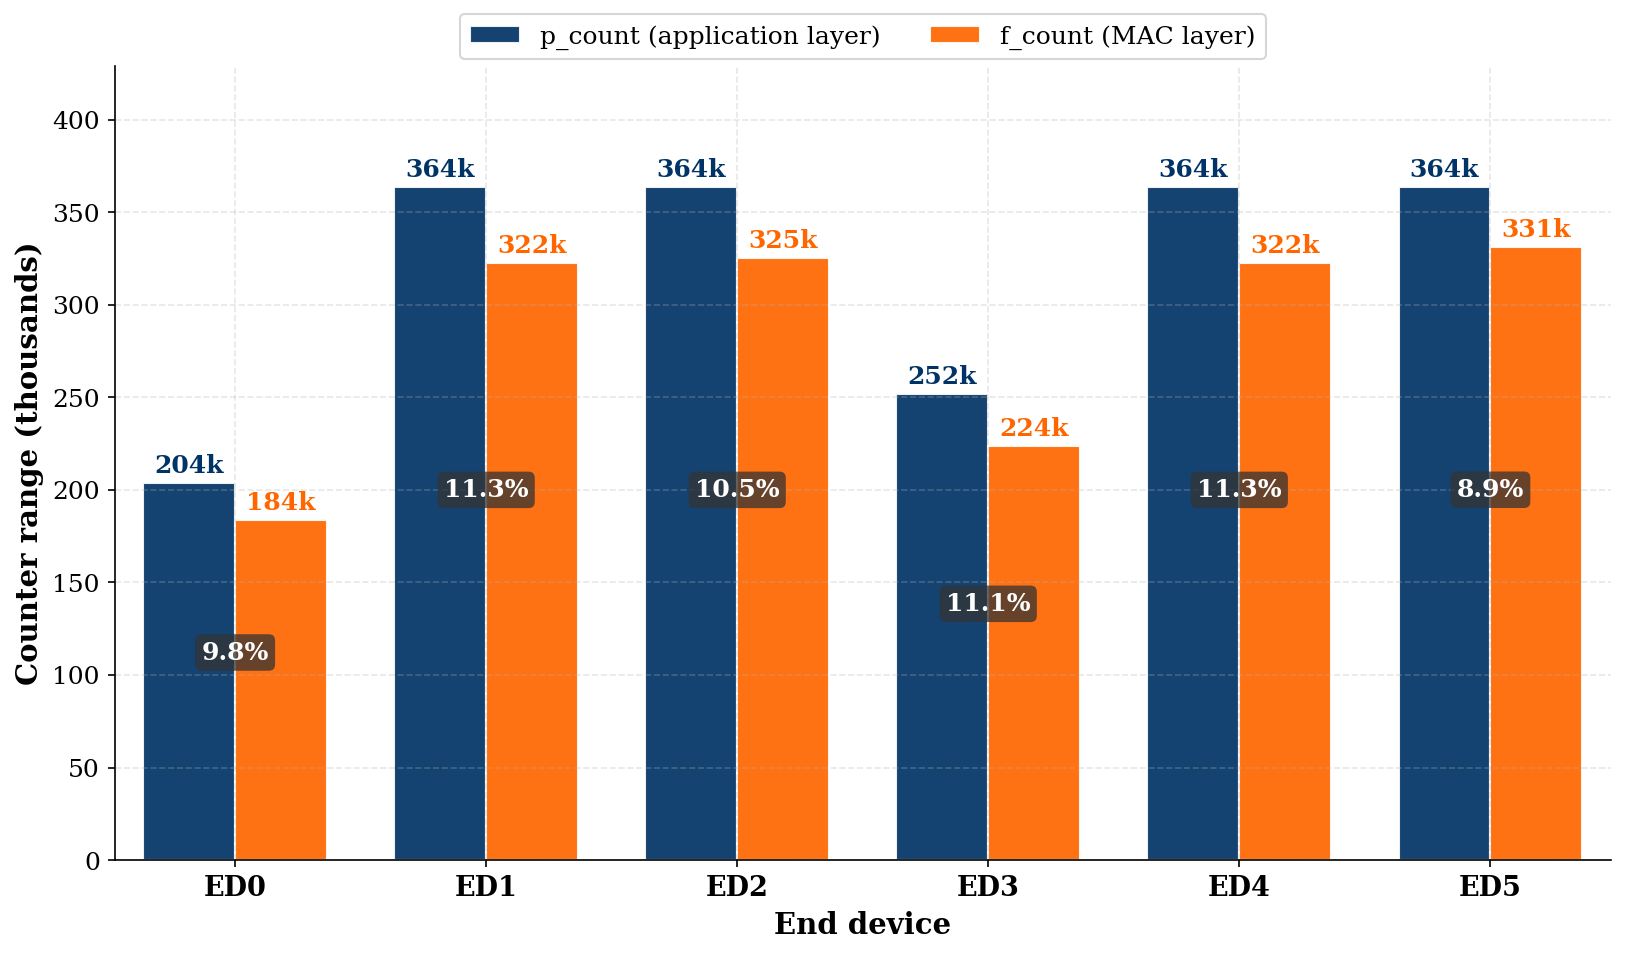

In [26]:
# Fig 01_a — p_count vs f_count divergence with fw drop rate annotated
DEVICES_D = div['device_id'].tolist()

# bring device groups closer together
x = np.arange(len(DEVICES_D)) * 0.82
w = 0.3

fig, ax = plt.subplots(figsize=(11, 6.5))

b1 = ax.bar(x - w / 2, div['p_range'] / 1000, w,
            color='#003366', alpha=0.92, edgecolor='white',
            label='p_count (application layer)')

b2 = ax.bar(x + w / 2, div['f_range'] / 1000, w,
            color='#FF6600', alpha=0.92, edgecolor='white',
            label='f_count (MAC layer)')

for bar_p, bar_f, row in zip(b1, b2, div.itertuples()):
    p_val = row.p_range / 1000
    f_val = row.f_range / 1000

    # p_count value on top
    ax.text(bar_p.get_x() + bar_p.get_width() / 2, p_val + 3,
            f'{p_val:.0f}k', ha='center', va='bottom',
            fontsize=12, color='#003366', fontweight='bold')

    # f_count value on top
    ax.text(bar_f.get_x() + bar_f.get_width() / 2, f_val + 3,
            f'{f_val:.0f}k', ha='center', va='bottom',
            fontsize=12, color='#FF6600', fontweight='bold')

    # fw drop rate between the two bars
    mid_x = (bar_p.get_x() + bar_p.get_width() + bar_f.get_x()) / 2
    ax.text(mid_x, max(p_val, f_val) * 0.55,
            f'{row.pct:.1f}%', ha='center', va='center',
            fontsize=12, fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.25',
                      facecolor='#333333', alpha=0.75,
                      edgecolor='none'))

ax.set_xticks(x)
ax.set_xticklabels(DEVICES_D, fontsize=13, fontweight='bold')
ax.set_ylabel('Counter range (thousands)', fontsize=14, fontweight='bold')
ax.set_xlabel('End device', fontsize=14, fontweight='bold')

ax.tick_params(axis='y', labelsize=12)
ax.tick_params(axis='x', labelsize=13)

ax.legend(
    fontsize=12,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.08),
    ncol=2,
    frameon=True
)
ax.margins(y=0.18, x=0.02)

fig.tight_layout()
save_fig(fig, '01_a_counter_divergence')

## 6 · Transmission Decomposition  *(§4.2.4 — Fig 01_b)*

The 2,634,930 intervals decompose into four categories accounting for all 3,101,814
scheduled transmissions ($T_{\text{sched}}$):

| Category | Condition | Role |
|----------|-----------|------|
| Clean reception | `tx_loss = 0`, `is_outage = False` | Successfully received |
| Firmware drops | `fw_drop > 0` | Dropped before radio — excluded from analysis |
| Link losses | `tx_loss > 0`, `is_outage = False` | **Primary analysis target** |
| Infrastructure outages | `is_outage = True` | Excluded from event analysis |

$\mathcal{D}_{\text{link}}$ = all non-outage intervals.


In [27]:
# Zone classification
df['loss_zone'] = np.select(
    [df['is_outage'], df['tx_loss'] == 0],
    ['outage', 'no_loss'],
    default='radio_loss'
)

# ── Interval counts ───────────────────────────────────────────────────────────
counts = df['loss_zone'].value_counts()
print(f'{"Zone":<15} {"Intervals":>12} {"Pct":>8}')
print('-' * 38)
for zone in ['no_loss', 'radio_loss', 'outage']:
    cnt = counts.get(zone, 0)
    print(f'{zone:<15} {cnt:>12,} {cnt / len(df) * 100:>7.2f}%')
print('-' * 38)
print(f'{"Total":<15} {len(df):>12,} {"100.00%":>8}')
print()

# ── Packet accounting (T_sched decomposition) ─────────────────────────────────
clean_pkts = df[df['loss_zone'] == 'no_loss'].shape[0]
fw_pkts = int(df['fw_drop'].sum())
link_pkts = int(df[df['loss_zone'] == 'radio_loss']['tx_loss'].sum())
outage_pkts = int(df[df['is_outage']]['tx_loss'].sum())
total_pkts = clean_pkts + fw_pkts + link_pkts + outage_pkts

print(f'{"Category":<25} {"Packets":>12} {"Pct":>8}')
print('-' * 47)
for label, val in [('Clean received', clean_pkts),
                   ('Firmware drops (fw_drop)', fw_pkts),
                   ('Link losses (tx_loss)', link_pkts),
                   ('Infrastructure outages', outage_pkts)]:
    print(f'{label:<25} {val:>12,} {val / total_pkts * 100:>7.2f}%')
print('-' * 47)
print(f'{"Total scheduled (T_sched)":<25} {total_pkts:>12,} {"100.00%":>8}')
print()
print(f'D_link (non-outage intervals) : {(~df["is_outage"]).sum():,}')

Zone               Intervals      Pct
--------------------------------------
no_loss            2,591,118   98.34%
radio_loss            43,646    1.66%
outage                   166    0.01%
--------------------------------------
Total              2,634,930  100.00%

Category                       Packets      Pct
-----------------------------------------------
Clean received               2,591,118   83.54%
Firmware drops (fw_drop)       251,370    8.10%
Link losses (tx_loss)          225,467    7.27%
Infrastructure outages          33,777    1.09%
-----------------------------------------------
Total scheduled (T_sched)    3,101,732  100.00%

D_link (non-outage intervals) : 2,634,764


  Saved: figures/01_b_loss_classification


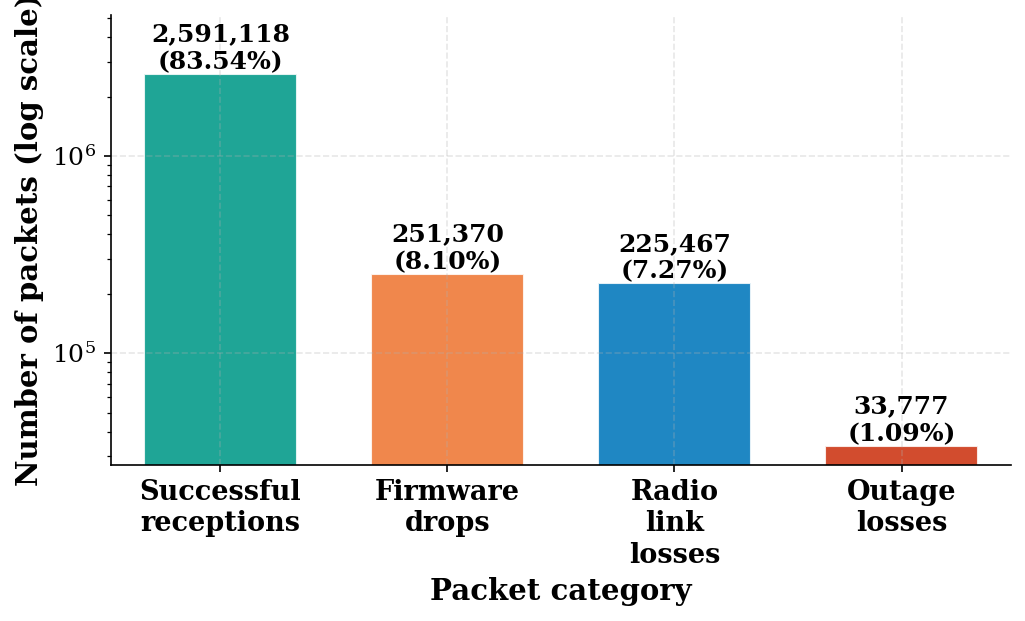

In [28]:
# Fig 01_c — Packet decomposition (§4.2.4)
pkt_labels = ['Successful\nreceptions', 'Firmware\ndrops', 'Radio\nlink\nlosses', 'Outage\nlosses']
pkt_counts = [clean_pkts, fw_pkts, link_pkts, outage_pkts]
pkt_colors = [C['green'], C['orange'], C['blue'], C['red']]
pkt_pcts = [v / total_pkts * 100 for v in pkt_counts]

# bring categories closer together
x = np.arange(len(pkt_labels)) * 0.82
w = 0.55

fig, ax = plt.subplots(figsize=(7, 4.3))

bars = ax.bar(x, pkt_counts, w, color=pkt_colors,
              alpha=0.88, edgecolor='white')
ax.set_yscale('log')

for bar, cnt, pct in zip(bars, pkt_counts, pkt_pcts):
    ax.text(bar.get_x() + bar.get_width() / 2, cnt,
            f'{cnt:,}\n({pct:.2f}%)',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

# Set y upper limit to give labels breathing room without going above plot
ax.set_ylim(bottom=ax.get_ylim()[0], top=max(pkt_counts) * 2)

ax.set_xticks(x)
ax.set_xticklabels(pkt_labels, fontsize=13, fontweight='bold')
ax.set_ylabel('Number of packets (log scale)', fontsize=14, fontweight='bold')
ax.set_xlabel('Packet category', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=12)
ax.margins(x=0.04)

# Made title bold and updated the LaTeX math block to use \mathbf for consistency
# ax.set_title(f'Packet Decomposition of the total scheduled transmissions ($\\mathbf{{T_{{\\mathrm{{sched}}}}}}$)', fontweight='bold')

fig.tight_layout()
save_fig(fig, '01_b_loss_classification')

## 7 · PDR Decomposition  *(§4.2.5 — Fig 01_c, Fig 01_d)*

Three PDR metrics, each isolating a different layer of the transmission pipeline:

| Metric | Losses included | Interpretation |
|--------|----------------|----------------|
| $\text{PDR}_{\text{system}}$ | $N_{\text{fw-drop}}$ + $N_{\text{tx-loss}}$ (all) | Application-layer reliability |
| $\text{PDR}_{\text{link+outage}}$ | $N_{\text{tx-loss}}$ (outages included) | Radio layer before outage filtering |
| $\text{PDR}_{\text{link}}$ | $N_{\text{tx-loss}}$ (outages excluded) | **Primary metric** |

$\text{PDR}_{\text{link}}$ is used in all event-conditioned analysis in Notebook 03.


In [29]:
total_rx = len(df)
total_fw_drop = int(df['fw_drop'].sum())
total_tx_loss = int(df['tx_loss'].sum())

df_link = df[~df['is_outage']]
total_link_loss = int(df_link['tx_loss'].sum())

pdr_system = total_rx / (total_rx + total_fw_drop + total_tx_loss) * 100
pdr_link_outage = total_rx / (total_rx + total_tx_loss) * 100
pdr_link = len(df_link) / (len(df_link) + total_link_loss) * 100

print(f'PDR_system      : {pdr_system:.2f}%   (fw_drop + tx_loss all)')
print(f'PDR_link+outage : {pdr_link_outage:.2f}%   (tx_loss, outages included)')
print(f'PDR_link        : {pdr_link:.2f}%   (tx_loss, outages excluded)')
print()
print(f'Firmware drops account for  : {pdr_link_outage - pdr_system:.2f} pp')
print(f'Outage removal accounts for : {pdr_link - pdr_link_outage:.2f} pp')
print()
print('Per-device PDR_link:')
for dev, g in df_link.groupby('device_id'):
    rx = len(g)
    lost = int(g['tx_loss'].sum())
    dist = int(df[df['device_id'] == dev]['distance'].iloc[0])
    print(f'  {dev} ({dist}m): {rx / (rx + lost) * 100:.2f}%')

PDR_system      : 83.77%   (fw_drop + tx_loss all)
PDR_link+outage : 91.04%   (tx_loss, outages included)
PDR_link        : 92.12%   (tx_loss, outages excluded)

Firmware drops account for  : 7.28 pp
Outage removal accounts for : 1.07 pp

Per-device PDR_link:
  ED0 (10m): 91.84%
  ED1 (8m): 92.87%
  ED2 (23m): 93.83%
  ED3 (18m): 90.82%
  ED4 (37m): 91.04%
  ED5 (40m): 92.33%


## 8 · Per-Device Loss Breakdown  *(§4.2.5)*

Full decomposition per device. PDR_link values feed into thesis results.

`T_sched = Received + fw_drop + tx_loss(outage) + tx_loss(link)`


In [30]:
print(f'{"Dev":<6} {"Dist":^6} {"CW":^4} {"WW":^4} '
      f'{"Received":^10} {"fw_drop":^9} {"Outage":^9} {"Link Loss":^11} '
      f'{"PDR_sys":^9} {"PDR_l+o":^9} {"PDR_link":^10}')
print('-' * 105)

totals = {'rx': 0, 'fw': 0, 'outage': 0, 'link': 0}

for dev, g in df.groupby('device_id'):
    rx = len(g)
    fw = int(g['fw_drop'].sum())
    outage = int(g[g['is_outage']]['tx_loss'].sum())
    g_link = g[~g['is_outage']]
    link = int(g_link['tx_loss'].sum())
    radio_lost = outage + link

    for k, v in [('rx', rx), ('fw', fw), ('outage', outage), ('link', link)]:
        totals[k] += v

    pdr_sys = rx / (rx + fw + radio_lost) * 100
    pdr_lo = rx / (rx + radio_lost) * 100
    pdr_lnk = len(g_link) / (len(g_link) + link) * 100

    dist = int(g['distance'].iloc[0])
    cw = int(g['c_walls'].iloc[0])
    ww = int(g['w_walls'].iloc[0])

    print(f'{dev:<6} {dist:^6} {cw:^4} {ww:^4} '
          f'{rx:^10,} {fw:^9,} {outage:^9,} {link:^11,} '
          f'{pdr_sys:^9.2f} {pdr_lo:^9.2f} {pdr_lnk:^10.2f}')

print('-' * 105)
t = totals
radio_lost = t['outage'] + t['link']
print(f'{"Total":<6} {"":^6} {"":^4} {"":^4} '
      f'{t["rx"]:^10,} {t["fw"]:^9,} {t["outage"]:^9,} {t["link"]:^11,} '
      f'{t["rx"] / (t["rx"] + t["fw"] + radio_lost) * 100:^9.2f} '
      f'{t["rx"] / (t["rx"] + radio_lost) * 100:^9.2f} '
      f'{t["rx"] / (t["rx"] + t["link"]) * 100:^10.2f}')

Dev     Dist   CW   WW   Received   fw_drop   Outage    Link Loss   PDR_sys   PDR_l+o   PDR_link 
---------------------------------------------------------------------------------------------------------
ED0      10    0    0    440,166    39,670     3,524     39,116      84.25     91.17     91.84   
ED1      8     1    0    434,548    44,862    12,037     33,341      82.80     90.54     92.87   
ED2      23    0    2    440,920    42,083    12,836     28,986      84.01     91.34     93.83   
ED3      18    1    2    433,579    43,688     2,676     43,801      82.78     90.32     90.82   
ED4      37    0    5    435,416    45,534      995      42,829      82.97     90.86     91.04   
ED5      40    2    2    450,301    35,533     1,709     37,394      85.78     92.01     92.33   
---------------------------------------------------------------------------------------------------------
Total                   2,634,930   251,370   33,777     225,467     83.77     91.04     92.12   


  Saved: figures/01_c_pdr_decomposition


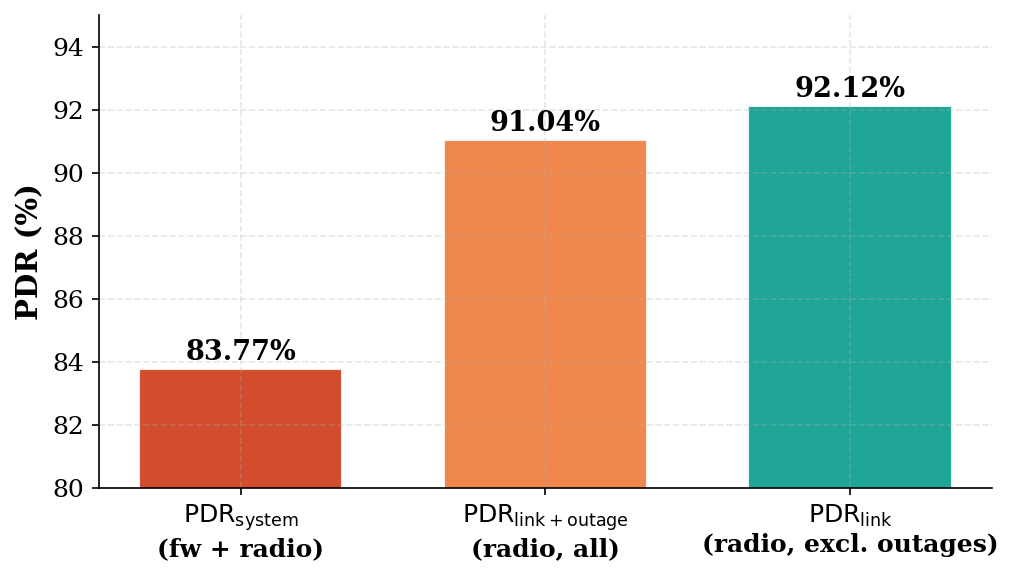

In [31]:
# Fig 01_c — PDR layer decomposition (§4.2.5)
fig, ax = plt.subplots(figsize=(7, 4))

categories = [
    r'$\mathrm{PDR_{system}}$' + '\n(fw + radio)',
    r'$\mathrm{PDR_{link+outage}}$' + '\n(radio, all)',
    r'$\mathrm{PDR_{link}}$' + '\n(radio, excl. outages)',
]
values_v = [pdr_system, pdr_link_outage, pdr_link]
colors_v = [C['red'], C['orange'], C['green']]

x = np.arange(len(categories)) * 0.75
w = 0.5
bars = ax.bar(x, values_v, w, color=colors_v,
              alpha=0.88, edgecolor='white')
for bar, v in zip(bars, values_v):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.1,
            f'{v:.2f}%', ha='center', va='bottom',
            fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
ax.set_ylim(80, 95)
ax.set_ylabel('PDR (%)', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=12)
ax.axhline(y=100, color='grey', lw=0.5, ls=':')
ax.margins(x=0.05)
# ax.set_title('PDR Decomposition\nSystem → Link+Outage → Link')

fig.tight_layout()
save_fig(fig, '01_c_pdr_decomposition')


  Saved: figures/01_d_pdr_per_device


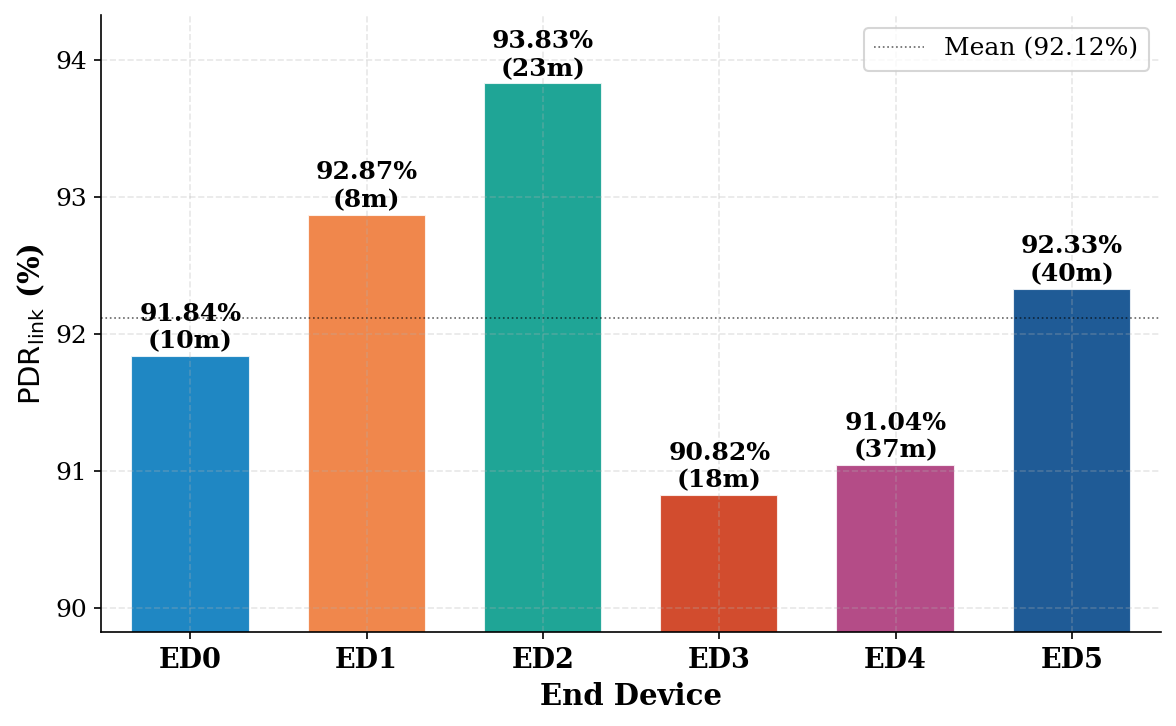

In [32]:

# ── Fig 01_d — PDR_link per device ───────────────────────────────────────────
DEVICES_P = sorted(df['device_id'].unique())
dev_pdrs, dev_dists = [], []
for dev in DEVICES_P:
    g = df_link[df_link['device_id'] == dev]
    rx = len(g)
    lost = int(g['tx_loss'].sum())
    dev_pdrs.append(rx / (rx + lost) * 100)
    dev_dists.append(int(df[df['device_id'] == dev]['distance'].iloc[0]))

# bring device bars closer together
x = np.arange(len(DEVICES_P)) * 0.82
w = 0.55

fig, ax = plt.subplots(figsize=(8, 5))

bars2 = ax.bar(x, dev_pdrs, w,
               color=DEVICE_COLORS[:len(DEVICES_P)],
               alpha=0.88, edgecolor='white')
for bar, v, d in zip(bars2, dev_pdrs, dev_dists):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02,
            f'{v:.2f}%\n({d}m)', ha='center', va='bottom',
            fontsize=12, fontweight='bold')
ax.axhline(y=pdr_link, color='black', lw=0.8, ls=':', alpha=0.6,
           label=f'Mean ({pdr_link:.2f}%)')
ax.set_xticks(x)
ax.set_xticklabels(DEVICES_P, fontsize=13, fontweight='bold')
ax.set_ylabel(r'$\mathrm{PDR_{link}}$ (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('End Device', fontsize=14, fontweight='bold')
ax.tick_params(axis='y', labelsize=12)
ax.set_ylim(min(dev_pdrs) - 1, max(dev_pdrs) + 0.5)
ax.margins(x=0.03)
# ax.set_title(r'$\mathrm{PDR_{link}}$ per Device (distance annotated)')
ax.legend(fontsize=12)

fig.tight_layout()
save_fig(fig, '01_d_pdr_per_device')

## 9 · Baseline PDR & Rolling Time Series  *(§7.1)*

Per-device `PDR_link` is the baseline metric for all event-conditioned analysis.  
The near-uniform PDR across devices with vastly different link budgets is the  
first evidence for the collision-dominated loss hypothesis.

The rolling time series shows PDR stability over the full campaign and  
confirms that outage exclusion (`is_outage`) correctly isolates environmental losses.


In [33]:
print(f"{'Device':<8} {'Dist(m)':^8} {'CW':^4} {'WW':^4} {'Received':^10} "
      f"{'Link Lost':^11} {'PDR_link':^10}")
print('-' * 65)

pdrs = {}
for dev, g in df_link.groupby('device_id'):
    rx = len(g)
    lost = int(g['tx_loss'].sum())
    pdr = rx / (rx + lost) * 100
    pdrs[dev] = pdr
    dist = int(g['distance'].iloc[0])
    cw = int(g['c_walls'].iloc[0])
    ww = int(g['w_walls'].iloc[0])
    print(f"{dev:<8} {dist:^8} {cw:^4} {ww:^4} {rx:^10,} {lost:^11,} {pdr:^10.2f}%")

print('-' * 65)
pdr_range = max(pdrs.values()) - min(pdrs.values())
print(f"PDR range across devices: {pdr_range:.2f} pp")
print(f"\nOnly {pdr_range:.2f} pp spread across devices with vastly different link budgets — "
      f"consistent with collision-dominated loss rather than signal quality degradation.")


Device   Dist(m)   CW   WW   Received   Link Lost   PDR_link 
-----------------------------------------------------------------
ED0         10     0    0    440,138     39,116      91.84   %
ED1         8      1    0    434,522     33,341      92.87   %
ED2         23     0    2    440,895     28,986      93.83   %
ED3         18     1    2    433,551     43,801      90.82   %
ED4         37     0    5    435,391     42,829      91.04   %
ED5         40     2    2    450,267     37,394      92.33   %
-----------------------------------------------------------------
PDR range across devices: 3.01 pp

Only 3.01 pp spread across devices with vastly different link budgets — consistent with collision-dominated loss rather than signal quality degradation.


  Saved: figures/01_e1_rolling_pdr_link_individual_7D


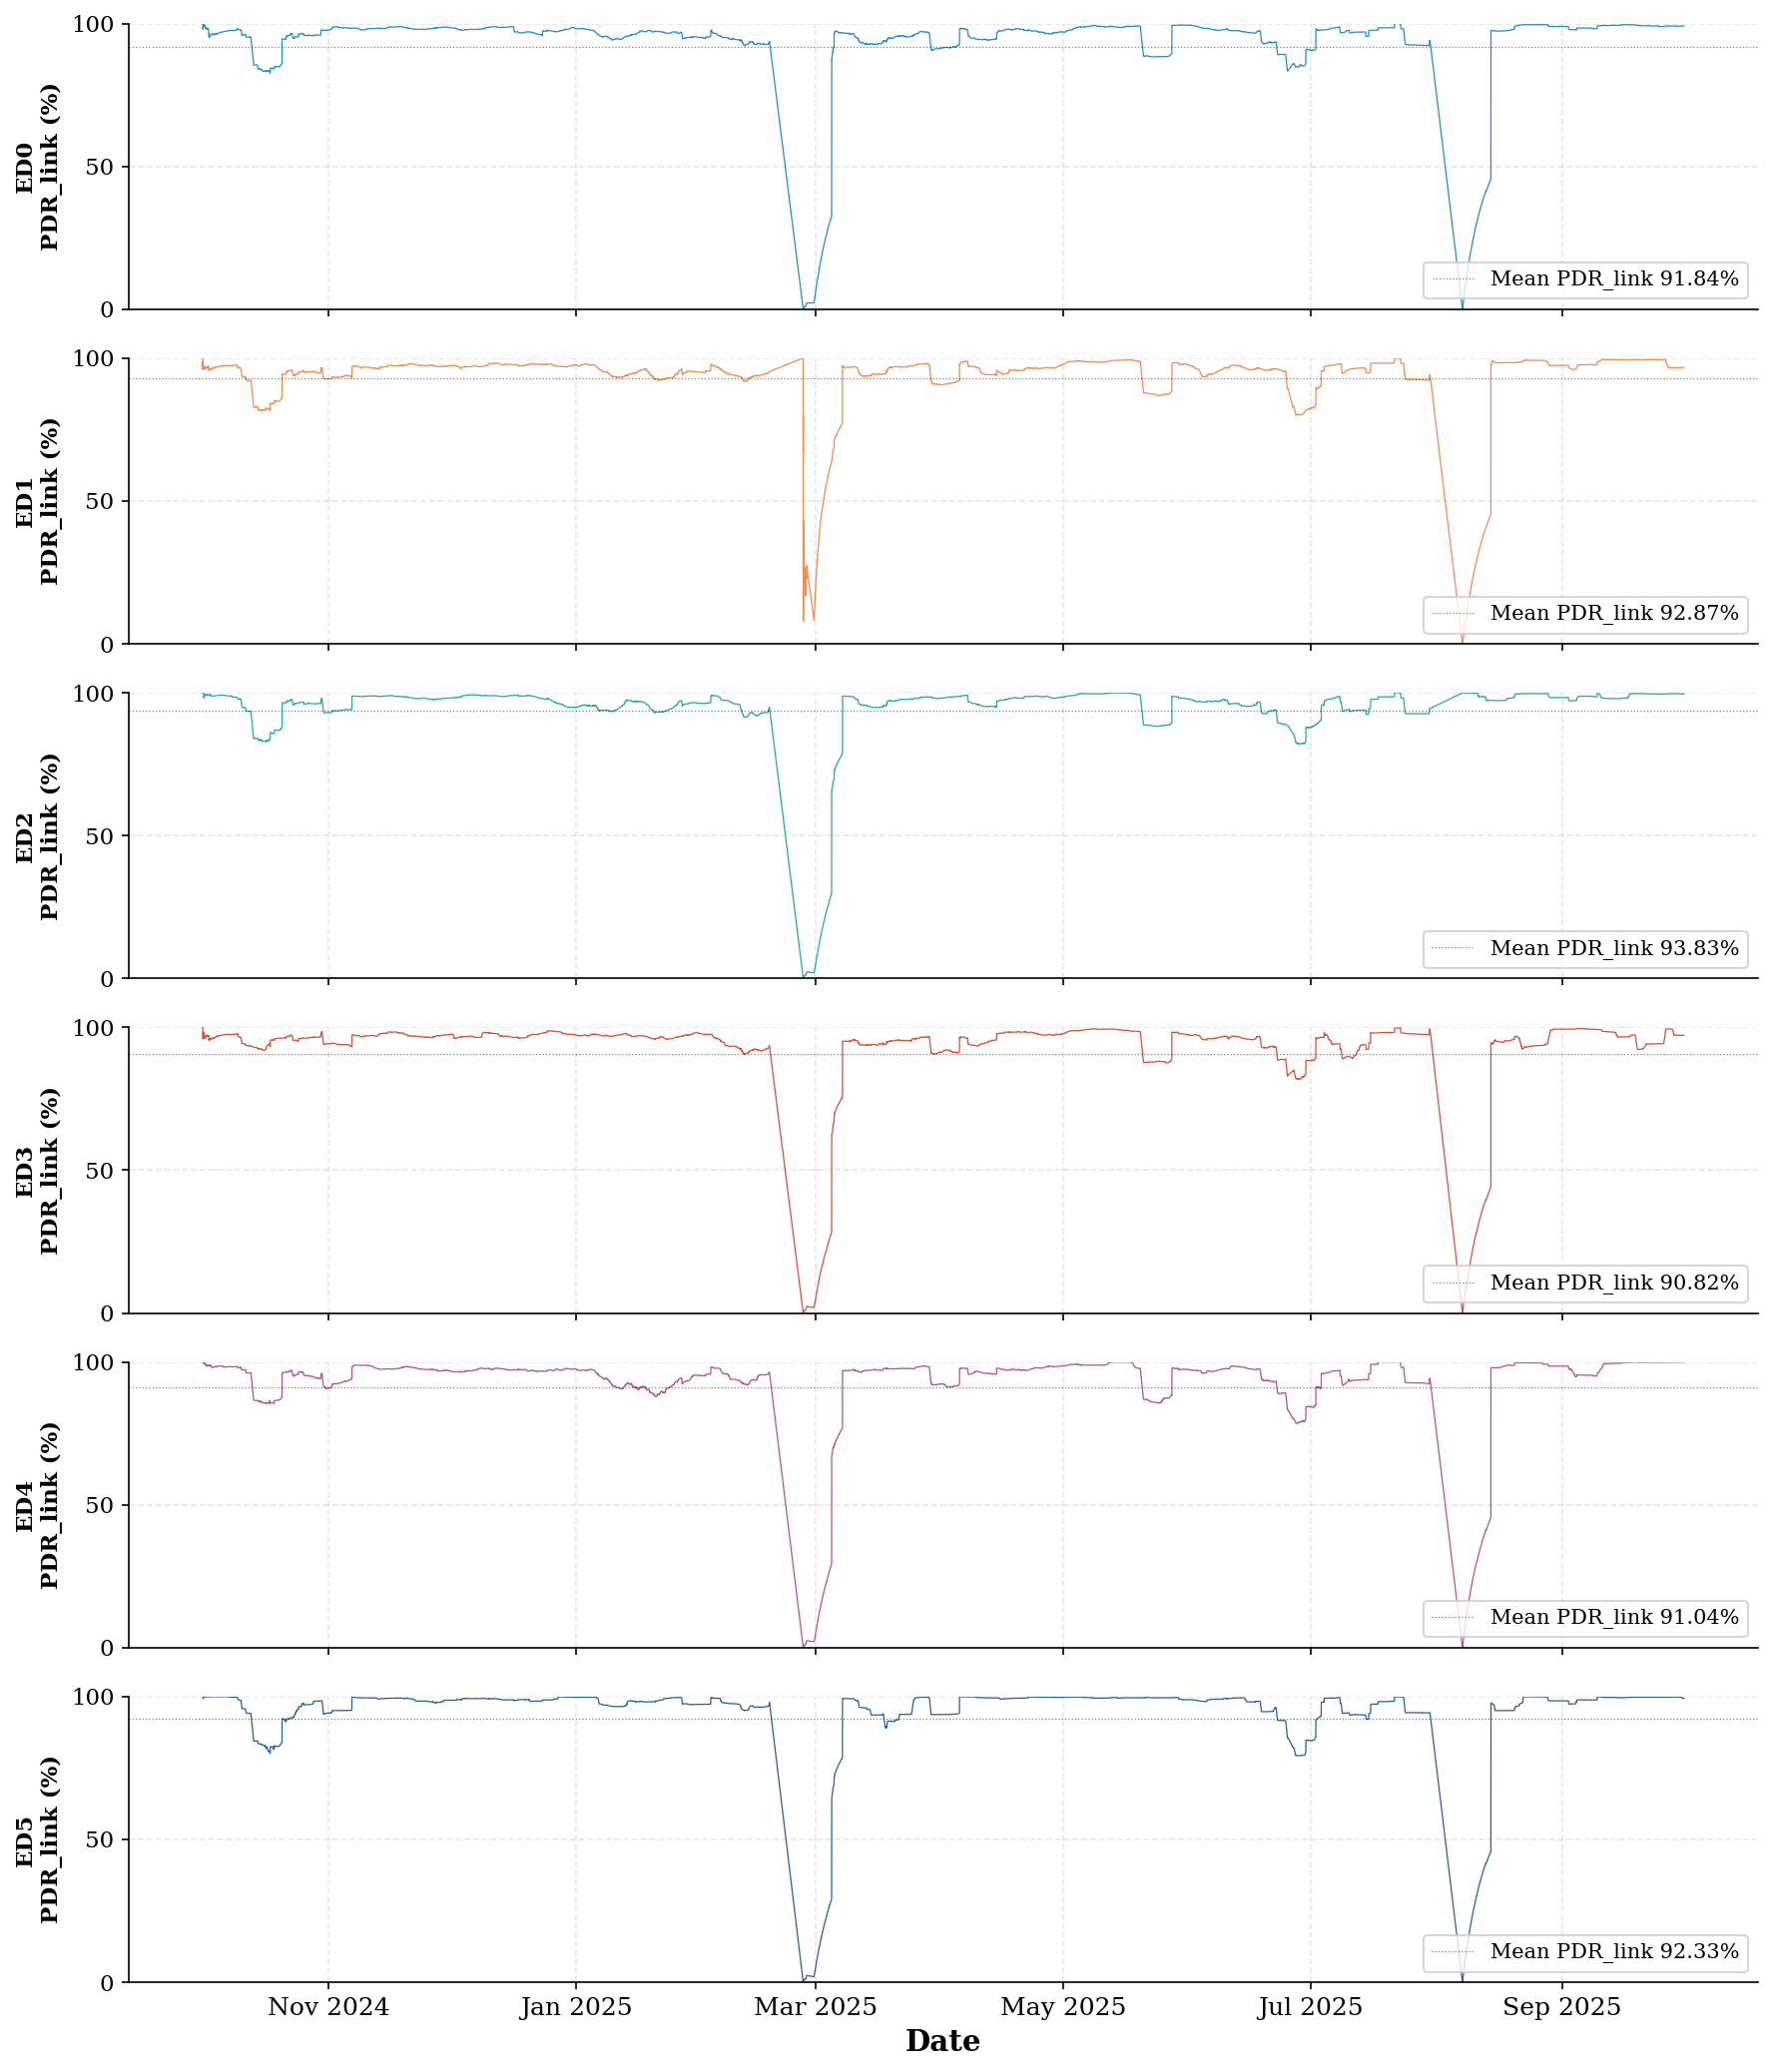

  Saved: figures/01_e2_rolling_pdr_link_superimposed_7D


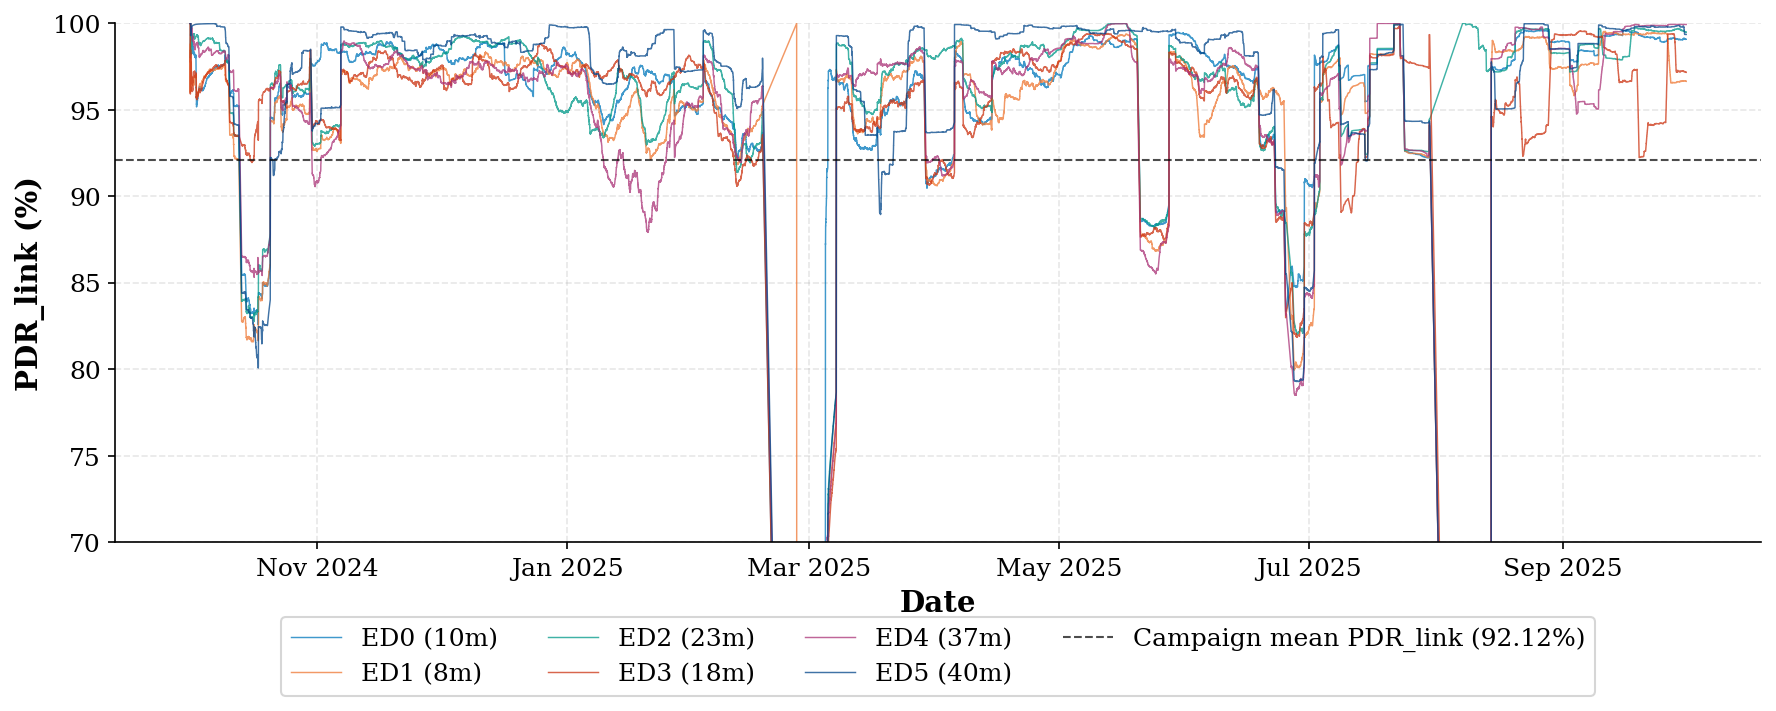

In [34]:
# Fig 01-E — Seven-day rolling PDR_link time series
ROLLING_WINDOW = '7D'  # options: '30min' | '2h' | '24h' | '7D'

DEVICES_A = sorted(df_link['device_id'].unique())

# ── Figure 1: individual subplots per device ─────────────────────────────
fig, axes = plt.subplots(6, 1, figsize=(12, 14), sharex=True)

for i, dev in enumerate(DEVICES_A):
    g = (
        df_link[df_link['device_id'] == dev]
        .copy()
        .set_index('time')
        .sort_index()
    )

    g['rx1'] = 1

    rpdr = (
            g['rx1'].rolling(ROLLING_WINDOW, min_periods=1).sum()
            / g['t_radio'].rolling(ROLLING_WINDOW, min_periods=1).sum()
            * 100
    ).clip(0, 100)

    axes[i].plot(
        rpdr.index,
        rpdr.values,
        linewidth=0.6,
        color=DEVICE_COLORS[i],
        alpha=0.85
    )

    pdr_link_dev = (
            len(g) / (len(g) + int(g['tx_loss'].sum())) * 100
    )

    axes[i].axhline(
        y=pdr_link_dev,
        color='black',
        lw=0.6,
        ls=':',
        alpha=0.5,
        label=f'Mean PDR_link {pdr_link_dev:.2f}%'
    )

    axes[i].set_ylabel(f'{dev}\nPDR_link (%)', fontsize=11, fontweight='bold')
    axes[i].set_ylim(0, 100)
    axes[i].set_yticks([0, 50, 100])
    axes[i].tick_params(axis='y', labelsize=11)
    axes[i].legend(fontsize=10, loc='lower right')

axes[-1].set_xlabel('Date', fontsize=14, fontweight='bold')
axes[-1].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
axes[-1].tick_params(axis='x', labelsize=12)

fig.tight_layout()
save_fig(fig, f'01_e1_rolling_pdr_link_individual_{ROLLING_WINDOW}')

# ── Figure 2: all devices superimposed on one axis ───────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

for i, dev in enumerate(DEVICES_A):
    g = (
        df_link[df_link['device_id'] == dev]
        .copy()
        .set_index('time')
        .sort_index()
    )

    g['rx1'] = 1

    rpdr = (
            g['rx1'].rolling(ROLLING_WINDOW, min_periods=1).sum()
            / g['t_radio'].rolling(ROLLING_WINDOW, min_periods=1).sum()
            * 100
    ).clip(0, 100)

    dist = int(g['distance'].iloc[0])

    ax.plot(
        rpdr.index,
        rpdr.values,
        linewidth=0.7,
        color=DEVICE_COLORS[i],
        alpha=0.75,
        label=f'{dev} ({dist}m)'
    )

# Campaign mean PDR_link across all devices
pdr_link_all = (
        len(df_link) / (len(df_link) + int(df_link['tx_loss'].sum())) * 100
)

ax.axhline(
    y=pdr_link_all,
    color='black',
    lw=1.0,
    ls='--',
    alpha=0.7,
    label=f'Campaign mean PDR_link ({pdr_link_all:.2f}%)'
)

ax.set_ylabel('PDR_link (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', labelsize=12)
ax.set_ylim(70, 100)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))

ax.legend(
    ncol=4,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.32),
    fontsize=12
)

fig.tight_layout()
fig.subplots_adjust(bottom=0.26)
save_fig(fig, f'01_e2_rolling_pdr_link_superimposed_{ROLLING_WINDOW}')

## 10 · Save  *(1_reconstructed.csv)*

| Group | Columns |
|-------|---------|
| Identifiers | `device_id`, `time` |
| Environmental | `co2`, `humidity`, `pm25`, `pressure`, `temperature` |
| Radio metrics | `rssi`, `snr`, `esp`, `SF`, `frequency`, `toa` |
| Spatial | `distance`, `c_walls`, `w_walls`, `exp_pl`, `n_power` |
| Raw counters | `f_count`, `p_count` |
| Derived | `tx_loss`, `fw_drop`, `t_radio`, `t_sched`, `is_reset`, `is_outage`, `loss_zone` |


In [35]:
original_cols = [
    'device_id', 'time',
    'co2', 'humidity', 'pm25', 'pressure', 'temperature',
    'rssi', 'snr', 'esp', 'SF', 'frequency', 'toa',
    'distance', 'c_walls', 'w_walls', 'exp_pl', 'n_power',
    'f_count', 'p_count',
]
derived_cols = [
    'tx_loss',  # N_tx-loss: transmitted but lost
    'fw_drop',  # N_fw-drop: firmware drop before radio
    't_radio',  # T_radio: total radio attempts
    't_sched',  # T_sched: total scheduled transmissions
    'is_reset',
    'is_outage',
    'loss_zone',
]

final_cols = (
        [c for c in original_cols if c in df.columns] +
        [c for c in derived_cols if c in df.columns]
)
df = df[final_cols]

df.to_csv(OUT_CSV, index=False)
print(f'Saved : {OUT_CSV}')
print(f'Rows  : {len(df):,}')
print(f'Cols  : {len(df.columns)}')

Saved : ..\data\1_reconstructed.csv
Rows  : 2,634,930
Cols  : 27
